<a href="https://colab.research.google.com/github/RodrigoCornelio/Exerc-cios/blob/main/Trabalho%20Jean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Index(['cidade ', 'População ', 'pib', 'gini', 'Bandalargam', 'bandalargaav',
       'equitec', 'escolaInter', 'compalunos', 'incdigital'],
      dtype='object')
Columns in top_10 DataFrame: Index(['cidade ', 'População ', 'pib', 'gini', 'Bandalargam', 'bandalargaav',
       'equitec', 'escolaInter', 'compalunos', 'incdigital', 'pontuacao'],
      dtype='object')
                  cidade   pontuacao
3853             Piratuba   0.901656
1680              Erechim   0.896941
729              Boracéia   0.888006
4375  Santa Cruz de Minas   0.855932
1254              Chapecó   0.854016
4606   São Caetano do Sul   0.817624
3897      Poços de Caldas   0.809298
2623    Juazeiro do Norte   0.800502
1735      Fagundes Varela   0.798668
1507             Curitiba   0.795787


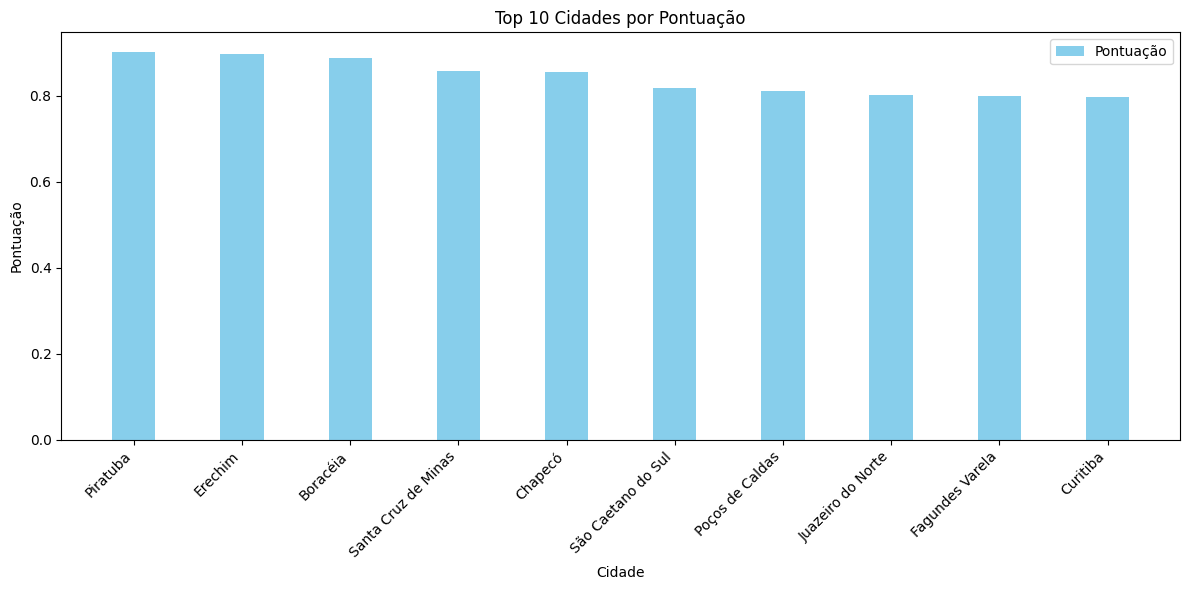

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

df = pd.read_excel('/content/Int.xlsx')

print(df.columns)

colunas_analise = ['População ', 'pib', 'gini', 'Bandalargam', 'bandalargaav',
       'equitec', 'escolaInter', 'compalunos', 'incdigital']

for col in colunas_analise:

  df[col] = df[col].astype(str).str.replace(',', '.', regex=False)
  df[col] = pd.to_numeric(df[col], errors='coerce')

scaler = MinMaxScaler()
df_normalizado = df.copy()
df_normalizado[colunas_analise] = scaler.fit_transform(df[colunas_analise])


pesos = {
    'População ': 0.1,
    'pib': 0.2,
    'gini': -0.2,
    'Bandalargam': 0.3,
    'bandalargaav': 0.2,
    'equitec': 0.25,
    'escolaInter': 0.25,
    'compalunos': 0.2,
    'incdigital': 0.3
}

df_normalizado['pontuacao'] = 0

for coluna, peso in pesos.items():
    df_normalizado['pontuacao'] += df_normalizado[coluna] * peso

    top_10 = df_normalizado.sort_values('pontuacao', ascending=False).head(10)

print("Columns in top_10 DataFrame:", top_10.columns)

print(top_10[['cidade ', 'pontuacao']])

tabela = pd.read_excel('/content/Int.xlsx')

df_plot = df_normalizado[['cidade ', 'pontuacao']]

df_plot = top_10[['cidade ', 'pontuacao']]

plt.figure(figsize=(12, 6))

bar_width = 0.4
x = range(len(df_plot))


plt.bar(x, df_plot['pontuacao'], width=bar_width, label='Pontuação', color='skyblue')

plt.xlabel('Cidade')
plt.ylabel('Pontuação')
plt.title('Top 10 Cidades por Pontuação')

plt.xticks([i for i in x], df_plot['cidade '], rotation=45, ha='right')
plt.legend()
plt.tight_layout()

